# ⚖️ Legal Intelligence System: Analysis & Insights
Developed by Antigravity AI Assistant

## 🎯 Objective
This notebook visualizes the experiments and results from the **Induction** and **Targeting** phases of the Legal Evidence Pipeline. Key goals:
1. Understand the distribution of 'Weak Cases' in the 10,000 judgment corpus.
2. Analyze evidence density across different legal categories.
3. Identify the 'Causal Gap' between successful and failed cases.

In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set Styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)

RESULTS_DIR = '/home/amaydixit11/Desktop/dev/Legal-Intelligence-System/results'

## 📊 Section 1: Corpus Composition
We scanned **9,703 judgments** to identify cases that were dismissed due to evidentiary weaknesses (e.g., 'benefit of doubt').

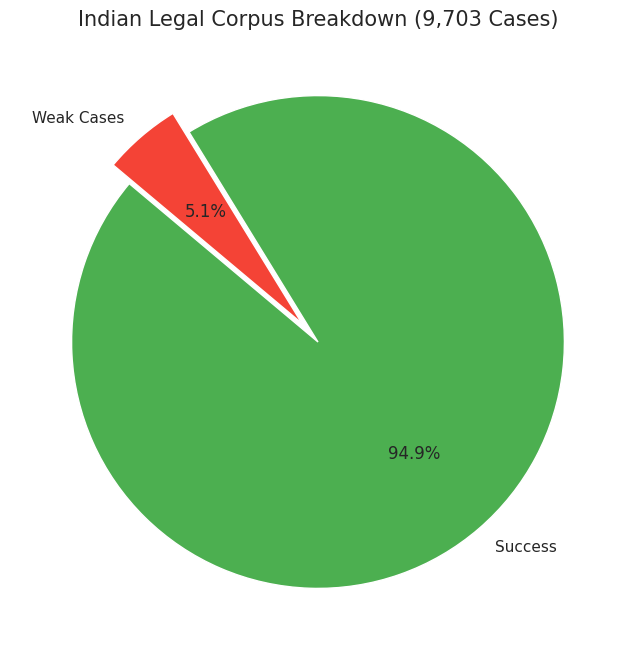

In [2]:
with open(f'{RESULTS_DIR}/failed_cases_index.json', 'r') as f:
    weak_cases = json.load(f)

total_cases = 9703
weak_count = len(weak_cases)
success_count = total_cases - weak_count

labels = ['Success', 'Weak Cases']
sizes = [success_count, weak_count]
colors = ['#4CAF50', '#F44336']

plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, explode=(0, 0.1))
plt.title('Indian Legal Corpus Breakdown (9,703 Cases)', fontsize=15)
plt.show()

## 🔬 Section 2: Evidence Mining Density
Results from the **Evidence Miner (Task 1.1)** showing the count of markers found per category in the 500-case pilot.

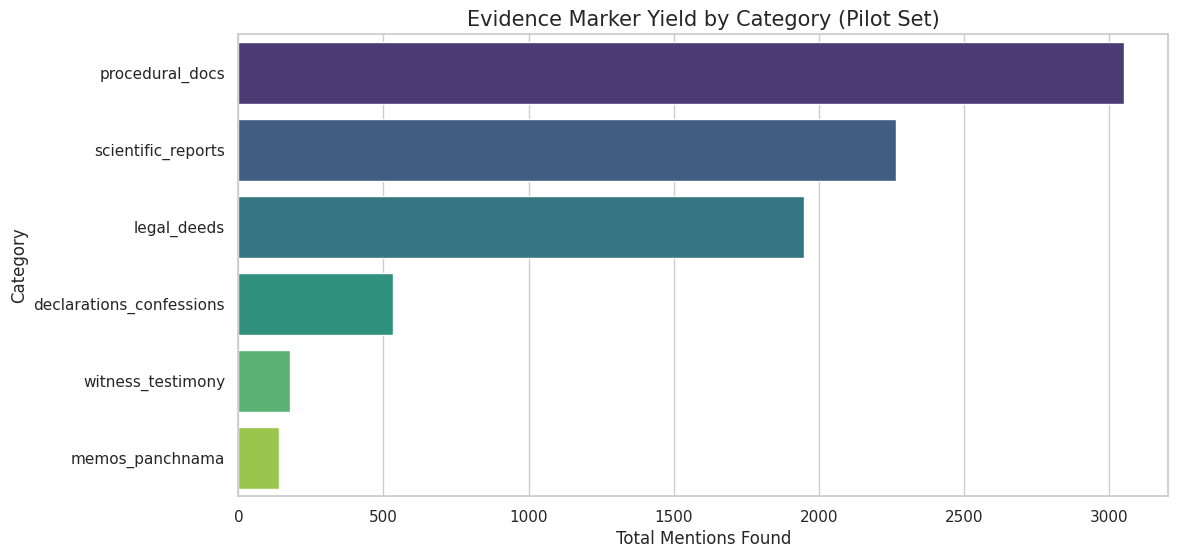

In [3]:
df_pilot = pd.read_csv(f'{RESULTS_DIR}/pilot_evidence_results.csv')
cat_counts = df_pilot['category'].value_counts().reset_index()
cat_counts.columns = ['Category', 'Mentions']

sns.barplot(data=cat_counts, x='Mentions', y='Category', hue='Category', palette='viridis', legend=False)
plt.title('Evidence Marker Yield by Category (Pilot Set)', fontsize=15)
plt.xlabel('Total Mentions Found')
plt.show()

## 🧠 Section 3: The Causal Gap Analysis
We compare the probability of findind an evidence marker in a **Success Case** vs a **Weak Case**.

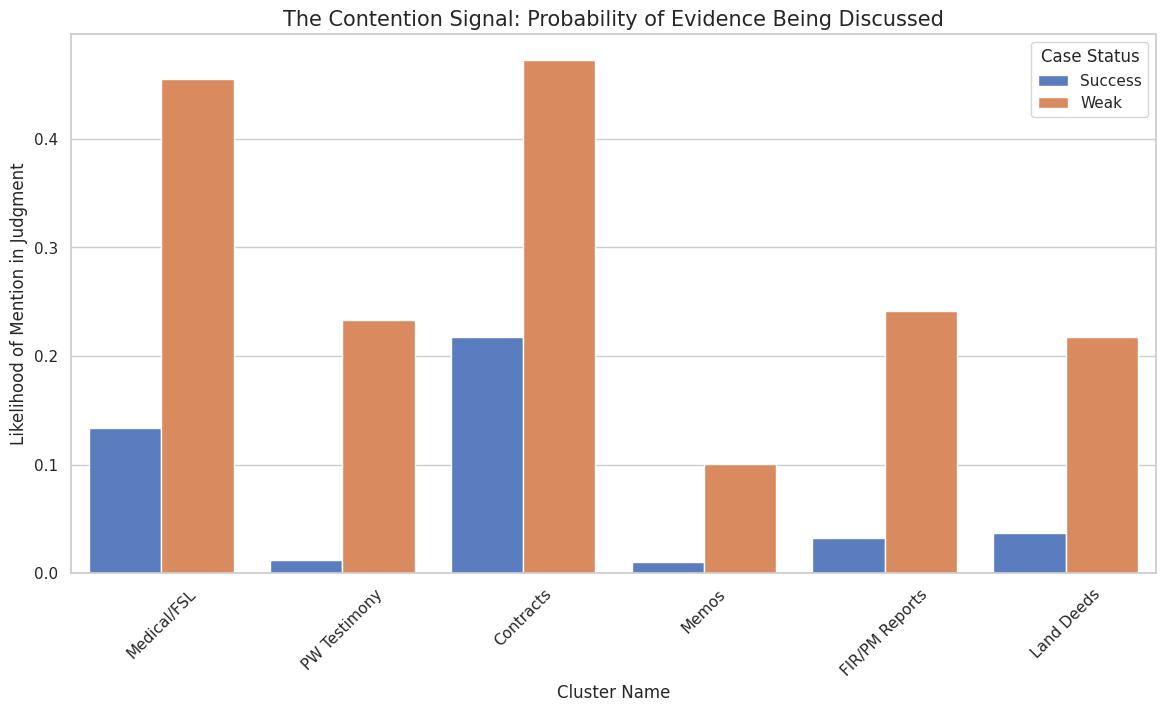

In [4]:
matrix_df = pd.read_csv(f'{RESULTS_DIR}/case_evidence_matrix.csv')
failed_ids = [c['case_id'] for c in weak_cases]
matrix_df['Case Status'] = matrix_df['case_id'].isin(failed_ids).map({True: 'Weak', False: 'Success'})

cluster_cols = [c for c in matrix_df.columns if c.startswith('cluster_')]
cluster_names = {
    'cluster_0': 'Medical/FSL',
    'cluster_1': 'PW Testimony',
    'cluster_2': 'Contracts',
    'cluster_3': 'Memos',
    'cluster_4': 'FIR/PM Reports',
    'cluster_5': 'Land Deeds'
}

stats = matrix_df.groupby('Case Status')[cluster_cols].mean().reset_index()
stats_melted = stats.melt(id_vars='Case Status', var_name='Cluster', value_name='Probability')
stats_melted['Cluster Name'] = stats_melted['Cluster'].map(cluster_names)

plt.figure(figsize=(14, 7))
sns.barplot(data=stats_melted, x='Cluster Name', y='Probability', hue='Case Status')
plt.title('The Contention Signal: Probability of Evidence Being Discussed', fontsize=15)
plt.ylabel('Likelihood of Mention in Judgment')
plt.xticks(rotation=45)
plt.show()